## Загрузка и первичная подготовка данных
Используемые библиотеки:

pandas — для работы с таблицами

numpy — для численных операций

matplotlib — интерфейс для создания графиков


In [79]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Загрузка файла датасета
from google.colab import files
files.upload()

# Настройки отображения
pd.set_option('display.max_columns', None)

# Просмотр первых строк
df.head()

Saving loan_prediction_cleaned.csv to loan_prediction_cleaned (13).csv


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,ApplicantIncome_log,LoanAmount_log
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,8.674197,4.859812
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,8.430327,4.859812
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,8.006701,4.204693
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,7.857094,4.795791
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,8.699681,4.955827


## Проверка отсутствия пропусков в датасете

In [80]:
df.isna().sum().sum()

np.int64(0)

## Поиск выбросов для ApplicantIncome и LoanAmount IQR-правилом

Формула:

*   IQR = Q3 - Q1
*   Нижняя граница = Q1 - 1.5 * IQR
*   Верхняя граница = Q3 + 1.5 * IQR

In [81]:
iqr_bounds = {}

for col in ['ApplicantIncome', 'LoanAmount']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    iqr_bounds[col] = (lower, upper)

iqr_outliers = {
    col: df[(df[col] < bounds[0]) | (df[col] > bounds[1])]
    for col, bounds in iqr_bounds.items()
}

{col: len(iqr_outliers[col]) for col in iqr_outliers}

{'ApplicantIncome': 50, 'LoanAmount': 41}

## Поиск выбросов для ApplicantIncome и LoanAmount методом стандартного отклонения (std)

Используемое правило для выбросов:
 - |x - mean| > 3 * std

In [82]:
std_bounds = {}

for col in ['ApplicantIncome', 'LoanAmount']:
    mean = df[col].mean()
    std = df[col].std()
    lower = mean - 3 * std
    upper = mean + 3 * std
    std_bounds[col] = (lower, upper)

std_outliers = {
    col: df[(df[col] < bounds[0]) | (df[col] > bounds[1])]
    for col, bounds in std_bounds.items()
}

{col: len(std_outliers[col]) for col in std_outliers}

{'ApplicantIncome': 8, 'LoanAmount': 15}

## Сравнение двух методов: IQR-правило и метод стандартного отклонения (std)

In [83]:
comparison = {}

for col in ['ApplicantIncome', 'LoanAmount']:
    iqr_set = set(iqr_outliers[col].index)
    std_set = set(std_outliers[col].index)
    comparison[col] = {
        "IQR_only": len(iqr_set - std_set),
        "STD_only": len(std_set - iqr_set),
        "Intersection": len(iqr_set & std_set)
    }

comparison

{'ApplicantIncome': {'IQR_only': 42, 'STD_only': 0, 'Intersection': 8},
 'LoanAmount': {'IQR_only': 26, 'STD_only': 0, 'Intersection': 15}}

## Объяснение различий

- Метод IQR устойчив к выбросам, ориентирован на медиану, следовательно находит больше умеренных выбросов.

- Метод стандартного отклонения чувствителен к экстремальным значениям, поэтому он находит только сильные выбросы.

#### Исходя из этого:
IQR обычно находит больше выбросов, STD же — только экстремальные хвосты.

## Визуальное подтверждение выбросов

###Boxplot

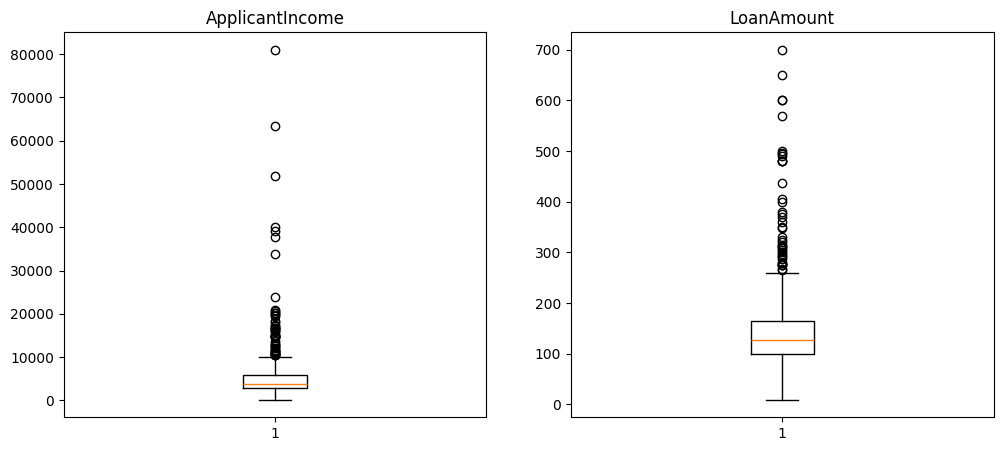

In [84]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.boxplot(df['ApplicantIncome'])
plt.title('ApplicantIncome')

plt.subplot(1,2,2)
plt.boxplot(df['LoanAmount'])
plt.title('LoanAmount')

plt.show()

###Гистограммы

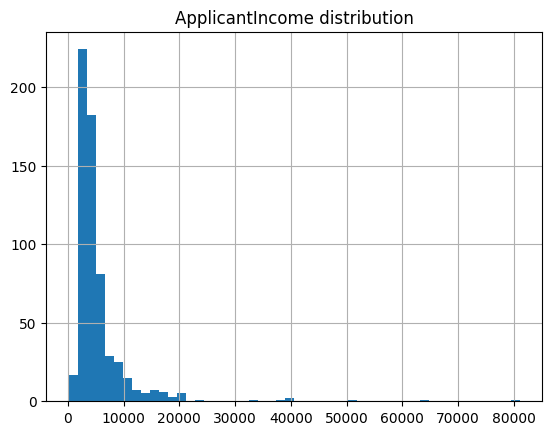

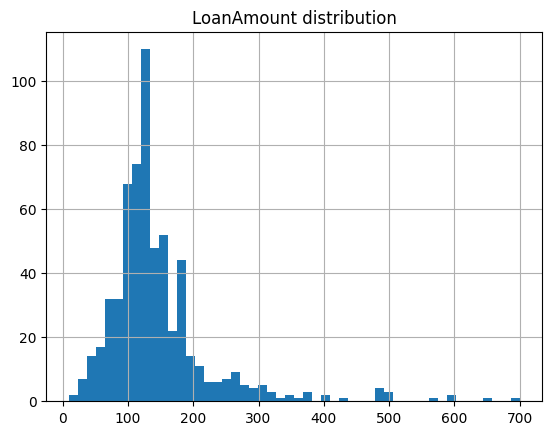

In [85]:
df['ApplicantIncome'].hist(bins=50)
plt.title('ApplicantIncome distribution')
plt.show()

df['LoanAmount'].hist(bins=50)
plt.title('LoanAmount distribution')
plt.show()

## Вывод
На графиках видно наличие выбросов и длинного правого хвоста. Это подтверждает асимметричность распределения и наличие экстремальных значений. Выбросы — экономически обоснованы (высокие доходы / крупные кредиты).

## Решение
Не удалять, а применить логарифмирование (log transform).


In [86]:
df['ApplicantIncome_log'] = np.log1p(df['ApplicantIncome'])
df['LoanAmount_log'] = np.log1p(df['LoanAmount'])

##Обоснование:

- удаление = потеря данных
- замена = искажение распределения
- логарифмирование = нормализация + сохранение информации

## Кодирование категориальных переменных

Выбраны следующие подходы:

- Бинарные признаки → числовое кодирование (0/1)
- Категориальные без порядка → One-Hot Encoding

Подход позволяет избежать ложного порядка и сохранить интерпретируемость.

In [87]:
# копия
df_encoded = df.copy()

# Label Encoding
binary_map = {'Male':1, 'Female':0,
              'Yes':1, 'No':0,
              'Graduate':1, 'Not Graduate':0}

df_encoded['Gender'] = df_encoded['Gender'].map(binary_map)
df_encoded['Married'] = df_encoded['Married'].map(binary_map)
df_encoded['Education'] = df_encoded['Education'].map(binary_map)
df_encoded['Self_Employed'] = df_encoded['Self_Employed'].map(binary_map)

# Dependents (ordinal)
df_encoded['Dependents'] = df_encoded['Dependents'].replace({'3+':3}).astype(int)

# One-hot encoding
df_encoded = pd.get_dummies(df_encoded, columns=['Property_Area'], drop_first=True)

df_encoded.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,ApplicantIncome_log,LoanAmount_log,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,Y,8.674197,4.859812,False,True
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,N,8.430327,4.859812,False,False
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,Y,8.006701,4.204693,False,True
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Y,7.857094,4.795791,False,True
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,Y,8.699681,4.955827,False,True


## Проверка результатов

In [88]:
df_encoded.info()
df_encoded.shape
df_encoded.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loan_ID                  614 non-null    object 
 1   Gender                   614 non-null    int64  
 2   Married                  614 non-null    int64  
 3   Dependents               614 non-null    int64  
 4   Education                614 non-null    int64  
 5   Self_Employed            614 non-null    int64  
 6   ApplicantIncome          614 non-null    int64  
 7   CoapplicantIncome        614 non-null    float64
 8   LoanAmount               614 non-null    float64
 9   Loan_Amount_Term         614 non-null    float64
 10  Credit_History           614 non-null    float64
 11  Loan_Status              614 non-null    object 
 12  ApplicantIncome_log      614 non-null    float64
 13  LoanAmount_log           614 non-null    float64
 14  Property_Area_Semiurban  6

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
